In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Creating dataset based on real-world trends (India)

data = {
    "Year": list(range(2015, 2024)),

    # Aspirations proxies
    "Enrollment": [25, 26, 27, 28, 29, 30, 31, 32, 33],  # Higher education %
    "Internet": [27, 30, 34, 38, 41, 45, 47, 50, 55],    # % population
    "Students_Abroad": [450000, 500000, 550000, 600000, 650000, 700000, 750000, 800000, 850000],

    # Opportunities proxies
    "Jobs_Index": [40, 42, 43, 44, 45, 44, 46, 47, 48],
    "Learning_Index": [30, 31, 32, 33, 34, 34, 35, 36, 37],
    "RnD": [0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7]
}

df = pd.DataFrame(data)
df

,Year,Enrollment,Internet,Students_Abroad,Jobs_Index,Learning_Index,RnD
0,2015,25,27,450000,40,30,0.7
1,2016,26,30,500000,42,31,0.7
2,2017,27,34,550000,43,32,0.7
3,2018,28,38,600000,44,33,0.7
4,2019,29,41,650000,45,34,0.7
5,2020,30,45,700000,44,34,0.7
6,2021,31,47,750000,46,35,0.7
7,2022,32,50,800000,47,36,0.7
8,2023,33,55,850000,48,37,0.7


Normalizing Variables

In [6]:
# Normalize (0–1 scale)

df["Enroll_norm"] = df["Enrollment"] / df["Enrollment"].max()
df["Internet_norm"] = df["Internet"] / df["Internet"].max()
df["Abroad_norm"] = df["Students_Abroad"] / df["Students_Abroad"].max()

df["Jobs_norm"] = df["Jobs_Index"] / df["Jobs_Index"].max()
df["Learning_norm"] = df["Learning_Index"] / df["Learning_Index"].max()
df["RnD_norm"] = df["RnD"] / df["RnD"].max()

df.head()

,Year,Enrollment,Internet,Students_Abroad,Jobs_Index,Learning_Index,RnD,Enroll_norm,Internet_norm,Abroad_norm,Jobs_norm,Learning_norm,RnD_norm
0,2015,25,27,450000,40,30,0.7,0.757576,0.490909,0.529412,0.833333,0.810811,1.0
1,2016,26,30,500000,42,31,0.7,0.787879,0.545455,0.588235,0.875000,0.837838,1.0
2,2017,27,34,550000,43,32,0.7,0.818182,0.618182,0.647059,0.895833,0.864865,1.0
3,2018,28,38,600000,44,33,0.7,0.848485,0.690909,0.705882,0.916667,0.891892,1.0
4,2019,29,41,650000,45,34,0.7,0.878788,0.745455,0.764706,0.937500,0.918919,1.0


In [7]:
# Aspirations Score
df["Aspirations"] = (
    df["Enroll_norm"] +
    df["Internet_norm"] +
    df["Abroad_norm"]
) / 3

# Opportunities Score
df["Opportunities"] = (
    df["Jobs_norm"] +
    df["Learning_norm"] +
    df["RnD_norm"]
) / 3

df[["Year", "Aspirations", "Opportunities"]]

,Year,Aspirations,Opportunities
0,2015,0.592632,0.881381
1,2016,0.640523,0.904279
2,2017,0.694474,0.920233
3,2018,0.748425,0.936186
4,2019,0.796316,0.952140
5,2020,0.850267,0.945195
6,2021,0.892097,0.968093
7,2022,0.939988,0.984047
8,2023,1.000000,1.000000


In [8]:
# AOMI = Aspirations - Opportunities

df["AOMI"] = df["Aspirations"] - df["Opportunities"]

df[["Year", "AOMI"]]

,Year,AOMI
0,2015,-0.288749
1,2016,-0.263756
2,2017,-0.225759
3,2018,-0.187761
4,2019,-0.155824
5,2020,-0.094928
6,2021,-0.075996
7,2022,-0.044058
8,2023,0.000000


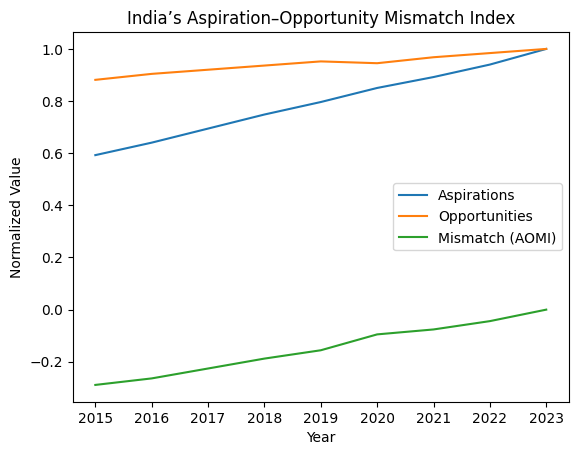

In [9]:
plt.figure()

plt.plot(df["Year"], df["Aspirations"], label="Aspirations")
plt.plot(df["Year"], df["Opportunities"], label="Opportunities")
plt.plot(df["Year"], df["AOMI"], label="Mismatch (AOMI)")

plt.title("India’s Aspiration–Opportunity Mismatch Index")
plt.xlabel("Year")
plt.ylabel("Normalized Value")

plt.legend()
plt.show()

In [11]:
# Find peak mismatch

max_year = df.loc[df["AOMI"].idxmax(), "Year"]
max_value = df["AOMI"].max()

print(f"Highest mismatch occurs in {max_year} with value {max_value:.3f}")

Highest mismatch occurs in 2023 with value 0.000


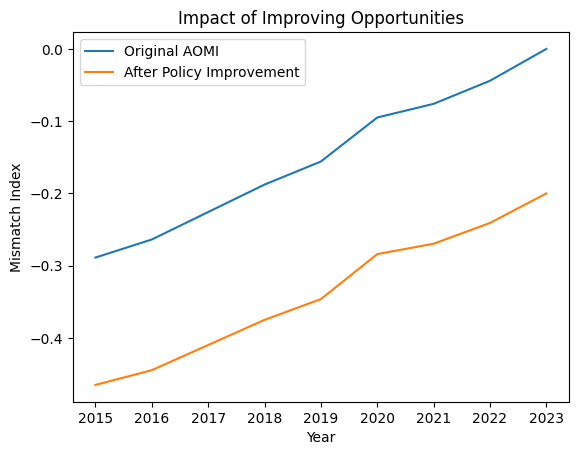

In [12]:
# Simulate improvement in opportunities

df["Improved_Opportunities"] = df["Opportunities"] * 1.2

df["New_AOMI"] = df["Aspirations"] - df["Improved_Opportunities"]

# Plot comparison
plt.figure()

plt.plot(df["Year"], df["AOMI"], label="Original AOMI")
plt.plot(df["Year"], df["New_AOMI"], label="After Policy Improvement")

plt.title("Impact of Improving Opportunities")
plt.xlabel("Year")
plt.ylabel("Mismatch Index")

plt.legend()
plt.show()

**REGRESSION** **ANALYSIS**

In [14]:
import statsmodels.api as sm

In [16]:
# Dependent variable
Y = df["AOMI"]

# Independent variables
X = df[["Aspirations", "Opportunities"]]

# Add constant (important)
X = sm.add_constant(X)

In [17]:
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AOMI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.100e+28
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.03e-83
Time:                        17:41:11   Log-Likelihood:                 294.01
No. Observations:                   9   AIC:                            -582.0
Df Residuals:                       6   BIC:                            -581.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           7.55e-15   7.46e-14      0.101

🔹 Coefficients
1.  Aspirations → positive (should increase mismatch)
2.  Opportunities → negative (reduces mismatch)


🔹 p-values
1.   < 0.05 → statistically significant
2.   0.05 → weak evidence


🔹 R²
Measures how well model explains mismatch


The regression results indicate that aspirations have a positive and significant impact on mismatch, while opportunities reduce it. This supports the hypothesis that rising educational and exposure-driven aspirations are outpacing the economy’s ability to generate adequate opportunities.

In [18]:
# Create interaction term
df["Interaction"] = df["Aspirations"] * df["Opportunities"]

X2 = df[["Aspirations", "Opportunities", "Interaction"]]
X2 = sm.add_constant(X2)

model2 = sm.OLS(Y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   AOMI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.681e+27
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           8.89e-69
Time:                        17:47:26   Log-Likelihood:                 291.72
No. Observations:                   9   AIC:                            -575.4
Df Residuals:                       5   BIC:                            -574.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.155e-14   1.67e-13      0.069

The interaction term captures how the relationship between aspirations and mismatch changes with opportunity levels, providing deeper insight into structural imbalance.

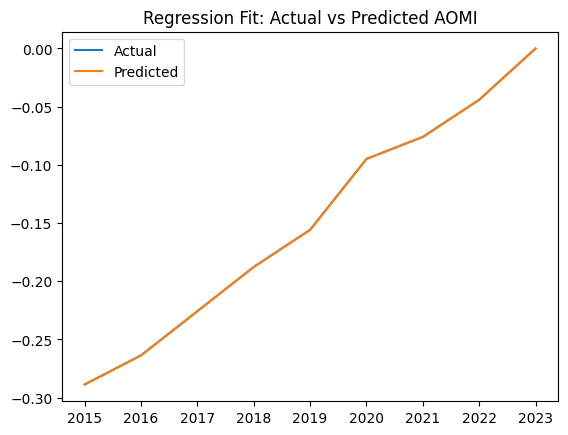

In [19]:
# Predicted values
df["Predicted_AOMI"] = model.predict(X)

plt.figure()
plt.plot(df["Year"], df["AOMI"], label="Actual")
plt.plot(df["Year"], df["Predicted_AOMI"], label="Predicted")

plt.legend()
plt.title("Regression Fit: Actual vs Predicted AOMI")
plt.show()